In [1]:
import pandas as pd

df = pd.read_csv('../datos/comentarios_deportivos.csv')

# asegurar que los datos sean texto
df['comentario'] = df['comentario'].astype(str)

df.head()

,id,comentario,sentimiento
0,180,"Partido equilibrado, resultado justo.",Neutral
1,177,"Encuentro equilibrado, reparto justo de puntos.",Neutral
2,189,Resultado esperado dadas las circunstancias.,Neutral
3,132,Nuestro ataque no generó peligro suficiente.,Negativo
4,148,"Sin sobresaltos, rendimiento promedio.",Neutral


In [2]:
# importar regular expresion
import re 

# funcion efectiva para limpiar texto
def limpiar_texto_simple(texto):
    # minusculas
    texto = texto.lower()
    # quita algunos caracteres, espacios
    texto = re.sub(r"[^a-záéíóúñü\s]", "", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

# aplicar limpieza
df['comentario_limpio'] = df['comentario'].apply(limpiar_texto_simple)

# revisar ejemplos
df[['comentario', 'comentario_limpio']].sample(10)


,comentario,comentario_limpio
71,Errores constantes en pases y posesión.,errores constantes en pases y posesión
66,La estrategia funcionó perfectamente.,la estrategia funcionó perfectamente
50,Ambos equipos tuvieron oportunidades.,ambos equipos tuvieron oportunidades
149,"Partido equilibrado, resultado justo.",partido equilibrado resultado justo
77,La defensa estuvo muy débil.,la defensa estuvo muy débil
24,Nuestro ataque no generó peligro suficiente.,nuestro ataque no generó peligro suficiente
192,"Victoria sólida, equipo muy bien organizado.",victoria sólida equipo muy bien organizado
20,Nuestro ataque no generó peligro suficiente.,nuestro ataque no generó peligro suficiente
166,"Encuentro equilibrado, reparto justo de puntos.",encuentro equilibrado reparto justo de puntos
81,"Mala estrategia, el técnico cometió errores.",mala estrategia el técnico cometió errores


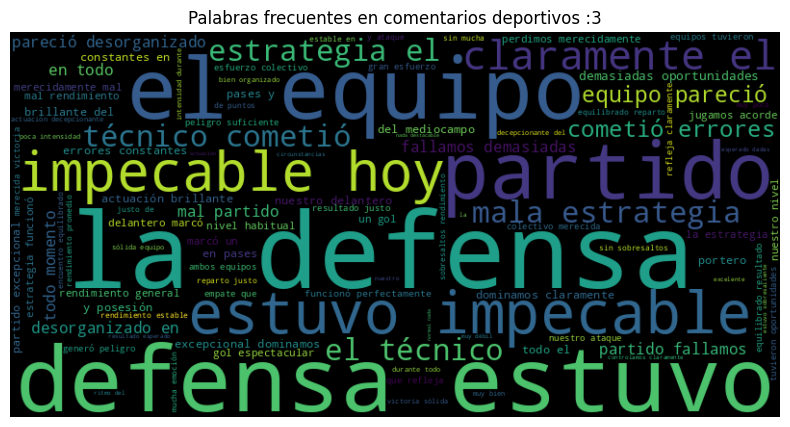

In [ ]:
# se hace una nube de palabras
from wordcloud import WordCloud
import matplotlib.pyplot  as plt

# filtrar comentarios utiles
df_filtrado = df[df['comentario_limpio'].str.strip().astype(bool)]

# une todos los comentarios limpios
texto_total = ' '.join(df_filtrado['comentario_limpio'])

# generar nube
if texto_total:
    wordCloud = WordCloud(width=800, height=400, background_color='black').generate(texto_total)
    plt.figure(figsize=(10,5))
    plt.imshow(wordCloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("Palabras frecuentes en comentarios deportivos :3")
    plt.show()
else:
    print('No hay palabras utiles')

/tmp/ipykernel_189145/3120841119.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentimiento', data=df, palette='viridis')


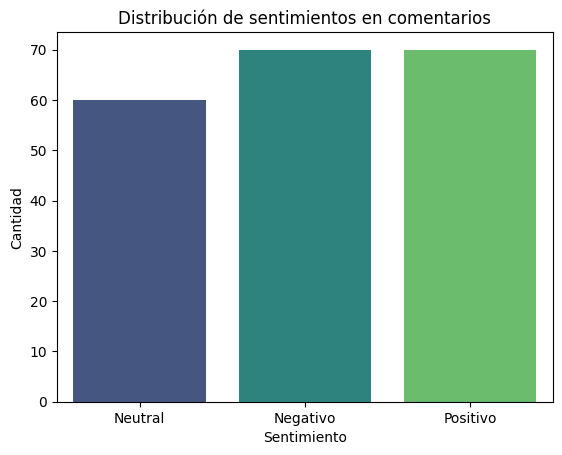

In [ ]:
# dibuja un grafico de barras con cada sentimiento
import seaborn as sns
import matplotlib.pyplot as plt
# verificar la columna
if 'sentimiento' in df.columns:
    sns.countplot(x='sentimiento', data=df, palette='viridis')
    plt.title('Distribución de sentimientos en comentarios')
    plt.xlabel('Sentimiento')
    plt.ylabel('Cantidad')
    plt.show()
else:
    print("No se encontro la columna 'sentimiento'.")

In [ ]:
# divide entre sentimientos y muestra 5 randoms
import ipywidgets as widgets
from IPython.display import display

sentimiento_widget = widgets.Dropdown(options=df['sentimiento'].unique(), description='Sentimiento: ')

def mostrar_comentarios(sentimiento):
    seleccionados = df[df['sentimiento'] == sentimiento]
    display(seleccionados[['comentario', 'comentario_limpio']].sample(5))

widgets.interactive(mostrar_comentarios, sentimiento=sentimiento_widget)

interactive(children=(Dropdown(description='Sentimiento: ', options=('Neutral', 'Negativo', 'Positivo'), value…